In [94]:
import os
import sys
import math
from statistics import mean
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from control import * 
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

from local_occupancy import sensor_measurements, sensor_distances
from local_occupancy import thymio_coords, sensor_pos_from_center, sensor_angles

from local import * 

In [95]:
import numpy as np
import math
import matplotlib.pyplot as plt

# --- 1) Straight path in WORLD frame ---
# Convention (matching your controller): 
#   - θ = 0 means the robot is facing +x.
# So we make a straight line along +x from 0 to 0.3 m.

path_length = 0.30        # 30 cm
num_points  = 60          # resolution of the path

x_path = np.linspace(0.0, path_length, num_points)
y_path = np.zeros(num_points)
path   = np.vstack((x_path, y_path)).T   # shape (N, 2)

# --- 2) Local occupancy grid (no obstacles) + navigator config ---
grid = LocalOccupancyGrid(
    size_m=0.4,           # 40 cm x 40 cm around the robot
    resolution_m=0.01,    # 1 cm cells
    hit_inc=0.3,
    decay=1.0             # no forgetting (doesn't matter here)
)

cfg = LocalNavConfig(
    lookahead_dist_m=0.10,
    max_lookahead_points=20,
    occ_threshold=0.5,
    rep_influence_radius=0.20,
    k_att=1.0,
    k_rep=0.0,            # no repulsion needed if we ignore obstacles
    virt_goal_dist_m=0.10
)

navigator = LocalNavigator(grid, cfg)

# --- 3) Go-to-goal controller for Thymio ---
gains = GoToGoalGains(
    Kv=2.0,
    Komega=6.0,
    v_max=0.12,   # 12 cm/s max
    w_max=4.0
)
kin   = ThymioKinematics()
g2g   = GoToGoalController(gains, kin)


In [96]:
# --- 4) Simulation parameters ---
dt      = 0.05            # 50 ms control step
T_sim   = 10.0            # total sim time
n_steps = int(T_sim / dt)

# Start pose: at (0, 0), facing +x (theta = 0)
pose = np.array([0.0, 0.0, 0.0])   # [x, y, theta]
traj = np.zeros((n_steps, 3))

final_goal = path[-1]

for k in range(n_steps):
    # (a) no obstacles: grid stays zero
    grid.grid[:] = 0.0

    # (b) local navigator: get virtual goal from path
    vg = navigator.compute_virtual_goal(pose, path)
    if vg is None:
        print("Navigator returned None, stopping.")
        traj = traj[:k]
        break

    # (c) go-to-goal controller: pose -> (uL, uR)
    uL, uR, info = g2g.compute_motor_commands(pose, vg, stop_if_close=False)

    # (d) convert motor commands back to (v, w) using the same kinematics
    r = kin.wheel_radius
    L = kin.half_axle
    phi_L = uL / kin.motor_gain
    phi_R = uR / kin.motor_gain

    v = r * (phi_R + phi_L) / 2.0
    w = r * (phi_R - phi_L) / (2.0 * L)

    # (e) integrate unicycle model
    pose[0] += v * math.cos(pose[2]) * dt
    pose[1] += v * math.sin(pose[2]) * dt
    pose[2]  = wrap_to_pi(pose[2] + w * dt)

    traj[k] = pose

    # (f) stop if we are close to the end of the segment
    dx = final_goal[0] - pose[0]
    dy = final_goal[1] - pose[1]
    if math.hypot(dx, dy) < 0.01:   # 1 cm tolerance
        print(f"Reached end of segment at step {k}")
        traj = traj[:k+1]
        break


Reached end of segment at step 57


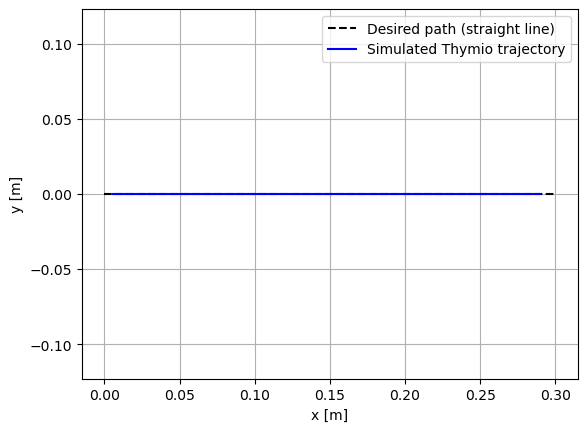

In [10]:
plt.figure()
plt.plot(path[:, 0], path[:, 1], "k--", label="Desired path (straight line)")
plt.plot(traj[:, 0], traj[:, 1], "b-",  label="Simulated Thymio trajectory")
plt.axis("equal")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.grid(True)
plt.legend()
plt.show()


In [76]:
from tdmclient import ClientAsync

client = ClientAsync()
node = await client.wait_for_node()
await node.lock()


Node 848cf03d-8bca-4685-9cca-f00b771ebd9e

In [55]:
def motors(l_speed=0, r_speed=0):
    return {
        "motor.left.target":  [int(l_speed)],
        "motor.right.target": [int(r_speed)],
    }


In [82]:
await node.set_variables(motors(0, 0))


In [67]:
import numpy as np
import math

# --- straight path along +x, from 0 to 0.3 m ---
path_length = 0.3 # 30 cm
num_points  = 60

x_path = np.linspace(0.0, path_length, num_points)
y_path = np.zeros(num_points)
path   = np.vstack((x_path, y_path)).T   # (N,2)

# --- local occupancy grid (not really used yet, no obstacles) ---
grid = LocalOccupancyGrid(
    size_m=0.6,          # 40x40 cm local map
    resolution_m=0.01,   # 1 cm
    hit_inc=0.6,
    decay=0.98            # no forgetting, doesn't matter now
)

cfg = LocalNavConfig(
    lookahead_dist_m=0.15,
    max_lookahead_points=30,
    occ_threshold=0.3,
    rep_influence_radius=0.30,
    k_att=1.0,
    k_rep=1.5,           # no repulsion (no obstacles in this test)
    virt_goal_dist_m=0.10
)

navigator = LocalNavigator(grid, cfg)

# --- go-to-goal controller + kinematics ---
gains = GoToGoalGains(
    Kv=2,
    Komega=1.5, #3?
    v_max=0.18,   # 0.12 m/s = 12 cm/s
    w_max=2.0
)
kin   = ThymioKinematics(
    wheel_radius=0.022,
    half_axle=0.0475,
    motor_gain=10.0,
    motor_max=300
)
g2g   = GoToGoalController(gains, kin)


In [46]:
async def follow_straight_segment_tdm(
    path,
    dt=0.01,
    max_time_s=10.0,
    goal_tol_m=0.02,
):
    """
    Make Thymio follow a straight segment using LocalNavigator + GoToGoalController.
    - path: (N,2) array in WORLD frame (here, along +x)
    """

    # Make sure the Thymio variables are available
    await node.wait_for_variables()

    # Starting pose: at beginning of the path, facing +x
    pose = np.array([path[0, 0], path[0, 1], 0.0], dtype=float)  # [x, y, theta]
    final_goal = path[-1]

    n_steps = int(max_time_s / dt)
    print("Starting straight-segment follow...")

    uL_prev = 0
    uR_prev = 0
    alpha_smooth = 0.4    # 0.0 = no smoothing, 1.0 = very aggressive smoothing


    for k in range(n_steps):
        # No obstacles for now: keep occupancy grid empty
        grid.grid[:] = 0.0

        # 1) Local nav: compute virtual goal from current pose + path
        vg = navigator.compute_virtual_goal(pose, path)
        if vg is None:
            print("Navigator returned None, stopping.")
            break

        # 2) Go-to-goal controller: pose -> motor commands
        uL, uR, info = g2g.compute_motor_commands(pose, vg, stop_if_close=False)
                # Exponential smoothing on motor commands
        uL = int(alpha_smooth * uL_prev + (1.0 - alpha_smooth) * uL)
        uR = int(alpha_smooth * uR_prev + (1.0 - alpha_smooth) * uR)

        uL_prev, uR_prev = uL, uR

        # 3) Send motor commands to Thymio
        await node.set_variables(motors(uL, uR))

        # 4) Integrate pose using commanded velocities (open-loop odometry)
        r = kin.wheel_radius
        L = kin.half_axle

        # convert motor units -> wheel angular speeds (rad/s)
        phi_L = uL / kin.motor_gain
        phi_R = uR / kin.motor_gain

        v = r * (phi_R + phi_L) / 2.0          # linear velocity [m/s]
        w = r * (phi_R - phi_L) / (2.0 * L)    # angular velocity [rad/s]

        pose[0] += v * math.cos(pose[2]) * dt
        pose[1] += v * math.sin(pose[2]) * dt
        pose[2]  = wrap_to_pi(pose[2] + w * dt)

        # 5) wait for the next control step
        await client.sleep(dt)

        # 6) check distance to final goal
        dx = final_goal[0] - pose[0]
        dy = final_goal[1] - pose[1]
        dist_to_goal = math.hypot(dx, dy)

        if k % 10 == 0:
            print(f"step {k}, dist_to_goal = {dist_to_goal:.3f} m, commands = ({uL}, {uR})")

        if dist_to_goal < goal_tol_m:
            print(f"Reached goal within {goal_tol_m*100:.1f} cm at step {k}")
            break

    # Stop the robot
    await node.set_variables(motors(0, 0))
    print("Stopped.")


In [47]:
await follow_straight_segment_tdm(path)


Starting straight-segment follow...
step 0, dist_to_goal = 0.299 m, commands = (48, 48)
step 10, dist_to_goal = 0.282 m, commands = (80, 80)
step 20, dist_to_goal = 0.264 m, commands = (80, 80)
step 30, dist_to_goal = 0.247 m, commands = (80, 80)
step 40, dist_to_goal = 0.229 m, commands = (80, 80)
step 50, dist_to_goal = 0.211 m, commands = (80, 80)
step 60, dist_to_goal = 0.194 m, commands = (80, 80)
step 70, dist_to_goal = 0.176 m, commands = (80, 80)
step 80, dist_to_goal = 0.159 m, commands = (80, 80)
step 90, dist_to_goal = 0.141 m, commands = (80, 80)
step 100, dist_to_goal = 0.123 m, commands = (80, 80)
step 110, dist_to_goal = 0.106 m, commands = (80, 80)
step 120, dist_to_goal = 0.088 m, commands = (80, 80)
step 130, dist_to_goal = 0.072 m, commands = (66, 66)
step 140, dist_to_goal = 0.059 m, commands = (54, 54)
step 150, dist_to_goal = 0.048 m, commands = (44, 44)
step 160, dist_to_goal = 0.040 m, commands = (36, 36)
step 170, dist_to_goal = 0.032 m, commands = (30, 30)
ste

In [70]:
await node.unlock()


In [68]:
async def follow_segment_with_avoid(path,
                                    dt=0.10,
                                    max_time_s=20.0,
                                    goal_tol_m=0.02):
    """
    Follow the given path (straight line) and use local navigation
    + Thymio's prox.horizontal sensors to avoid obstacles and
    come back to the path.
    """
    # Make sure variables are available
    await node.wait_for_variables({"prox.horizontal"})

    # Start pose at the beginning of the path, facing +x
    pose = np.array([path[0, 0], path[0, 1], 0.0], dtype=float)
    final_goal = path[-1]

    n_steps = int(max_time_s / dt)
    print("Starting path following with obstacle avoidance...")

    for k in range(n_steps):
        # 1) Read Thymio horizontal proximity sensors (7 values)
        sensor_vals = list(node.v.prox.horizontal)
        # Example: [prox0, prox1, ..., prox6]

        # 2) Update occupancy grid from sensor values
        grid.update_from_sensor_vals(sensor_vals)

                # DEBUG: occupancy stats
        max_occ = np.max(grid.grid)
        num_above_01 = np.sum(grid.grid > 0.1)
        num_above_thr = np.sum(grid.grid > cfg.occ_threshold)

        if k % 10 == 0:
            print(f"[DEBUG] max_occ={max_occ:.3f}, "
                f"cells>0.1={num_above_01}, "
                f"cells>thr={num_above_thr}")


        # 3) Local navigator: compute virtual goal from pose + path + grid
        vg = navigator.compute_virtual_goal(pose, path)
        if vg is None:
            print("Navigator returned None, stopping.")
            break

        # 4) Go-to-goal controller: pose -> motor commands toward virtual goal
        uL, uR, info = g2g.compute_motor_commands(pose, vg,
                                                  stop_if_close=False,
                                                  tol=goal_tol_m)

        # 5) Send motor commands to Thymio
        await node.set_variables(motors(uL, uR))

        # 6) Integrate pose (open-loop odometry from commands)
        r = kin.wheel_radius
        L = kin.half_axle

        phi_L = uL / kin.motor_gain   # [rad/s] approx
        phi_R = uR / kin.motor_gain

        v = r * (phi_R + phi_L) / 2.0
        w = r * (phi_R - phi_L) / (2.0 * L)

        pose[0] += v * math.cos(pose[2]) * dt
        pose[1] += v * math.sin(pose[2]) * dt
        pose[2]  = wrap_to_pi(pose[2] + w * dt)

        # 7) Wait for next control step
        await client.sleep(dt)

        # 8) Check distance to final goal
        dx = final_goal[0] - pose[0]
        dy = final_goal[1] - pose[1]
        dist_to_goal = math.hypot(dx, dy)

        if k % 10 == 0:
            print(f"step {k}, dist_to_goal = {dist_to_goal:.3f} m, "
                  f"uL={uL}, uR={uR}, sensors={sensor_vals}")

        if dist_to_goal < goal_tol_m:
            print(f"Reached goal within {goal_tol_m*100:.1f} cm at step {k}")
            break

    # Stop robot
    await node.set_variables(motors(0, 0))
    print("Stopped.")


In [69]:
# Your straight path
path_length = 0.8
num_points  = 60
x_path = np.linspace(0.0, path_length, num_points)
y_path = np.zeros(num_points)
path   = np.vstack((x_path, y_path)).T

await follow_segment_with_avoid(path)


Starting path following with obstacle avoidance...
[DEBUG] max_occ=0.000, cells>0.1=0, cells>thr=0
step 0, dist_to_goal = 0.782 m, uL=81, uR=81, sensors=[0, 0, 0, 0, 0, 0, 0]
[DEBUG] max_occ=0.941, cells>0.1=2, cells>thr=2
step 10, dist_to_goal = 0.604 m, uL=81, uR=81, sensors=[0, 0, 0, 0, 0, 0, 0]
[DEBUG] max_occ=0.769, cells>0.1=9, cells>thr=9
step 20, dist_to_goal = 0.426 m, uL=81, uR=81, sensors=[0, 0, 0, 4049, 0, 0, 0]
[DEBUG] max_occ=1.000, cells>0.1=11, cells>thr=11
step 30, dist_to_goal = 0.248 m, uL=75, uR=88, sensors=[0, 0, 2249, 4311, 2906, 0, 0]
[DEBUG] max_occ=1.000, cells>0.1=25, cells>thr=25
step 40, dist_to_goal = 0.071 m, uL=76, uR=84, sensors=[3317, 2007, 3074, 4235, 0, 0, 0]
Reached goal within 2.0 cm at step 46
Stopped.


In [92]:
grid = LocalOccupancyGrid(
    size_m=0.6,
    resolution_m=0.01,
    hit_inc=0.6,
    decay=0.98,
    robot_radius_m=0.09  # tweak between 0.08–0.10

)

cfg = LocalNavConfig(
    lookahead_dist_m=0.15,
    max_lookahead_points=30,
    occ_threshold=0.3,
    rep_influence_radius=0.30,
    k_att=1.0,
    k_rep=1.5,
    virt_goal_dist_m=0.10
)

navigator = LocalNavigator(grid, cfg)

gains = GoToGoalGains(
    Kv=2.0,
    Komega=3.0,
    v_max=0.18,
    w_max=2.0
)
kin   = ThymioKinematics()
g2g   = GoToGoalController(gains, kin)


TypeError: LocalOccupancyGrid.__init__() got an unexpected keyword argument 'robot_radius_m'

In [73]:
path_length = 0.8
num_points  = 60
x_path = np.linspace(0.0, path_length, num_points)
y_path = np.zeros(num_points)
path   = np.vstack((x_path, y_path)).T


In [79]:
def motors(l_speed=0, r_speed=0):
    return {
        "motor.left.target":  [int(l_speed)],
        "motor.right.target": [int(r_speed)],
    }

async def follow_segment_with_avoid_debug(path,
                                          dt=0.10,
                                          max_time_s=20.0,
                                          goal_tol_m=0.02):
    await node.wait_for_variables({"prox.horizontal"})

    # Start pose at path start, facing along +x
    pose = np.array([path[0, 0], path[0, 1], 0.0], dtype=float)
    final_goal = path[-1]
    n_steps = int(max_time_s / dt)

    print("Starting path following with obstacle avoidance (DEBUG)...")

    for k in range(n_steps):
        # 1) Read Thymio sensors
        sensor_vals = list(node.v.prox.horizontal)

        # 2) Update occupancy grid
        grid.update_from_sensor_vals(sensor_vals)

        # DEBUG: grid stats
        max_occ = np.max(grid.grid)
        num_thr = np.sum(grid.grid > cfg.occ_threshold)

        # 3) Find look-ahead (LA) point on path
        LA_world, _ = navigator._find_lookahead_point(pose, path)
        if LA_world is None:
            print("No LA point, stopping.")
            break

        # 4) Express LA in robot frame
        p_LA_robot = navigator.world_to_robot(pose, LA_world)

        # 5) Attractive vector towards LA
        F_att = p_LA_robot.astype(float)
        norm_att = np.linalg.norm(F_att)
        if norm_att > 1e-6:
            F_att = (cfg.k_att / norm_att) * F_att

        # 6) Repulsive vector from grid
        F_rep = navigator._repulsive_vector()
        norm_rep = np.linalg.norm(F_rep)

        # 7) Total vector in robot frame
        F_tot = F_att + F_rep
        norm_tot = np.linalg.norm(F_tot)
        if norm_tot < 1e-6:
            F_tot = np.array([0.0, 1.0], dtype=float)
            norm_tot = 1.0

        dir_robot = F_tot / norm_tot
        virt_robot = cfg.virt_goal_dist_m * dir_robot

        # 8) Convert virtual goal back to world frame
        virt_world = navigator.robot_to_world(pose, virt_robot)

        # 9) Controller: go to virtual goal
        uL, uR, info = g2g.compute_motor_commands(pose, virt_world,
                                                  stop_if_close=False,
                                                  tol=goal_tol_m)

        await node.set_variables(motors(uL, uR))

        # 10) Integrate pose from commanded speeds (open-loop)
        r = kin.wheel_radius
        L = kin.half_axle
        phi_L = uL / kin.motor_gain
        phi_R = uR / kin.motor_gain
        v = r * (phi_R + phi_L) / 2.0
        w = r * (phi_R - phi_L) / (2.0 * L)

        pose[0] += v * math.cos(pose[2]) * dt
        pose[1] += v * math.sin(pose[2]) * dt
        pose[2]  = wrap_to_pi(pose[2] + w * dt)

        # 11) Debug prints every few steps
        if k % 5 == 0:
            delta_VG_LA = np.linalg.norm(virt_world - LA_world)
            print(f"step {k} | dist_to_goal={math.hypot(final_goal[0]-pose[0], final_goal[1]-pose[1]):.3f} m")
            print(f"  sensors={sensor_vals}")
            print(f"  max_occ={max_occ:.3f}, cells>thr={num_thr}")
            print(f"  LA_world=({LA_world[0]:.3f},{LA_world[1]:.3f})")
            print(f"  VG_world=({virt_world[0]:.3f},{virt_world[1]:.3f}), |VG-LA|={delta_VG_LA:.3f}")
            print(f"  F_att=({F_att[0]:.3f},{F_att[1]:.3f}), F_rep=({F_rep[0]:.3f},{F_rep[1]:.3f})")
            print(f"  uL={uL}, uR={uR}")
            print("")

        # 12) Check if we reached final goal
        dx = final_goal[0] - pose[0]
        dy = final_goal[1] - pose[1]
        if math.hypot(dx, dy) < goal_tol_m:
            print(f"Reached goal within {goal_tol_m*100:.1f} cm at step {k}")
            break

        await client.sleep(dt)

    await node.set_variables(motors(0, 0))
    print("Stopped.")


In [81]:
await follow_segment_with_avoid_debug(path)


Starting path following with obstacle avoidance (DEBUG)...
step 0 | dist_to_goal=0.782 m
  sensors=[4339, 1452, 0, 0, 0, 0, 0]
  max_occ=1.000, cells>thr=28
  LA_world=(0.800,0.000)
  VG_world=(-0.100,-0.003), |VG-LA|=0.900
  F_att=(0.000,1.000), F_rep=(-4.156,-163.991)
  uL=125, uR=38

step 5 | dist_to_goal=0.713 m
  sensors=[4685, 4369, 0, 1500, 0, 4702, 0]
  max_occ=1.000, cells>thr=30
  LA_world=(0.800,0.000)
  VG_world=(0.022,0.048), |VG-LA|=0.779
  F_att=(0.869,0.494), F_rep=(-7.722,-157.091)
  uL=125, uR=38

step 10 | dist_to_goal=0.727 m
  sensors=[4687, 4368, 0, 1486, 0, 4704, 0]
  max_occ=1.000, cells>thr=30
  LA_world=(0.800,0.000)
  VG_world=(0.132,-0.027), |VG-LA|=0.669
  F_att=(0.820,-0.573), F_rep=(-7.722,-157.091)
  uL=125, uR=38

step 15 | dist_to_goal=0.809 m
  sensors=[4684, 4373, 0, 0, 1281, 3766, 0]
  max_occ=1.000, cells>thr=30
  LA_world=(0.800,0.000)
  VG_world=(0.125,-0.149), |VG-LA|=0.691
  F_att=(-0.104,-0.995), F_rep=(-19.537,-132.678)
  uL=125, uR=38

step 

CancelledError: 